In [1]:
# Upload zip file
from google.colab import files
uploaded = files.upload()

Saving images.zip to images.zip


In [2]:
# Extract zip
import zipfile
import os

zip_path = "images.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# Check folders
os.listdir("dataset")

['images']

In [5]:
import cv2
import numpy as np
import os

IMG_SIZE = 64

data = []
labels = []

dataset_path = "dataset/images"
classes = []
for folder in os.listdir(dataset_path):
    if os.path.isdir(os.path.join(dataset_path, folder)):
        classes.append(folder)

print("Classes:", classes)

for label, category in enumerate(classes):
    path = os.path.join(dataset_path, category)

    for img in os.listdir(path):
        img_path = os.path.join(path, img)

        image = cv2.imread(img_path)

        if image is None:
            print("Skipping:", img_path)
            continue

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image / 255.0

        data.append(image)
        labels.append(label)

X = np.array(data)
y = np.array(labels)

print("Loaded images:", len(X))
print("Shape:", X.shape)

Classes: ['pizza', 'sunflower', 'dalmatian', 'soccer_ball', 'dollar_bill']
Loaded images: 309
Shape: (309, 64, 64, 3)


In [6]:
X = X.reshape(X.shape[0], -1)
print("Flattened shape:", X.shape)

Flattened shape: (309, 12288)


In [7]:
print(np.unique(y))

[0 1 2 3 4]


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier()

grid = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [10]:
best_rf = grid.best_estimator_

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7258064516129032
              precision    recall  f1-score   support

           0       0.78      0.64      0.70        11
           1       0.83      0.88      0.86        17
           2       0.65      0.73      0.69        15
           3       0.43      0.33      0.38         9
           4       0.82      0.90      0.86        10

    accuracy                           0.73        62
   macro avg       0.70      0.70      0.70        62
weighted avg       0.72      0.73      0.72        62



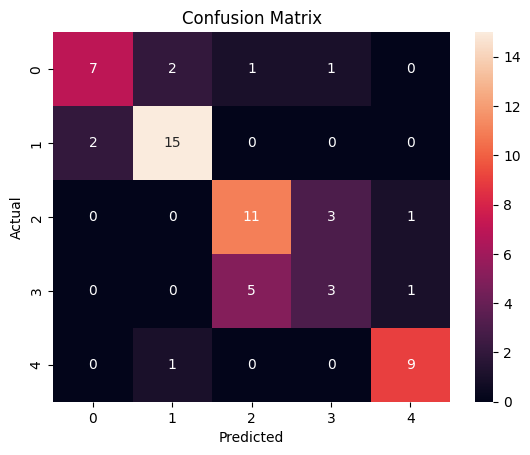

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

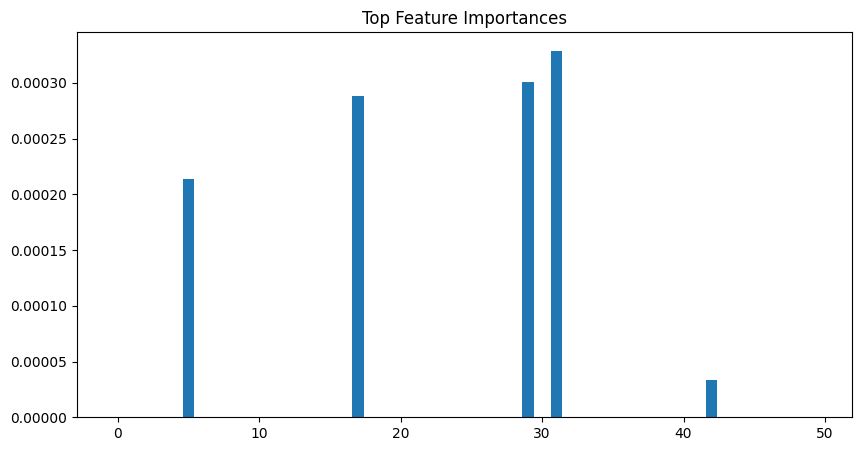

In [13]:
importances = best_rf.feature_importances_

# Plot top features
plt.figure(figsize=(10,5))
plt.bar(range(50), importances[:50])
plt.title("Top Feature Importances")
plt.show()

In [14]:
def predict_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = img.reshape(1, -1)

    pred = best_rf.predict(img)
    return classes[pred[0]]

In [16]:
import os

print(os.listdir("dataset/images/pizza")[:5])

['image_0005.jpg', 'image_0045.jpg', 'image_0018.jpg', 'image_0048.jpg', 'image_0023.jpg']


In [17]:
import os

sample_class = classes[0]  # e.g. 'pizza'
sample_image = os.listdir(f"dataset/images/{sample_class}")[0]

image_path = f"dataset/images/{sample_class}/{sample_image}"

print("Testing with:", image_path)

predict_image(image_path)

Testing with: dataset/images/pizza/image_0005.jpg


'pizza'

In [18]:
import matplotlib.pyplot as plt

def predict_and_show(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print("Invalid image path")
        return

    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_norm = img_resized / 255.0
    img_flat = img_norm.reshape(1, -1)

    pred = best_rf.predict(img_flat)
    label = classes[pred[0]]

    # Show image
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Predicted: {label}")
    plt.axis("off")
    plt.show()

In [19]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.7580645161290323


In [20]:
import pickle

with open("rf_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)